In [ ]:
#                                   ANN (VALIDATION METHOD) CLASSIFICATION DATASET 

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout

In [7]:
df=pd.read_csv(r'C:\Users\amank\Downloads\DEEP LEARNING ANN\Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.drop(columns=['RowNumber','CustomerId','Surname','Geography'],inplace=True)

In [14]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,encoded_Gender
0,619,42,2,0.00,1,1,1,101348.88,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0


In [ ]:
#                         ENCODE THE CATEGORICAL COLUMNS

In [10]:
label=LabelEncoder()

In [11]:
df['encoded_Gender']=label.fit_transform(df['Gender'])

In [13]:
df.drop(columns=['Gender'],inplace=True)

In [ ]:
#                                         DATA SPLITING 

In [15]:
x=df.drop(columns=['Exited'])
y=df['Exited']

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#                                           MODEL SELECTION 

#                                   ADDING DROPOT 

In [39]:
model=Sequential()

In [42]:
model.add(Dense(512,activation='relu',input_dim=(9)))
model.add(Dropout(0.1))

model.add(Dense(256,activation='relu'))  # CAN DO THIS WAS AS WELL  model.add(Dense(128)) SELECT RELU DEFAULT.
model.add(Dropout(0.1))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,977 (2.68 MB)

 Trainable params: 702,977 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.get_weights()  #AT LAST IT SHOES BIAS AND ABOVE ITS SHOWS TRAINABL PARAMETERS.

[array([[-0.13007523, -0.09758543, -0.12121978, ..., -0.12795849,
          0.04828835,  0.01802935],
        [ 0.14829437, -0.0131155 , -0.05449951, ...,  0.01129533,
         -0.1457268 , -0.09689527],
        [-0.08257272, -0.03702745,  0.13012071, ..., -0.12405948,
         -0.11220337,  0.08184029],
        ...,
        [ 0.10609888,  0.10009743, -0.14180572, ..., -0.10658911,
         -0.07879253, -0.12862307],
        [-0.00082082,  0.02799529, -0.00513081, ...,  0.12645881,
         -0.11772501,  0.06372629],
        [-0.07214864,  0.15013228,  0.14748727, ..., -0.07124233,
          0.07759164, -0.12645881]], shape=(9, 256), dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.

In [ ]:
#                       COMPILE THE DATA

In [44]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#                          VALIDATION TEST 

#   INCREASE EPOCHS TRY THIS FOR INCREASING ACCURACY AS NORMALY WE TAKE 10 EPOCHS

#   

In [45]:
history=model.fit(x_train,y_train,batch_size=32,epochs=50,validation_split=0.2)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.6709 - loss: 89.4743 - val_accuracy: 0.7569 - val_loss: 2.9903
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6795 - loss: 2.6465 - val_accuracy: 0.7987 - val_loss: 0.5483
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.7036 - loss: 0.9513 - val_accuracy: 0.7987 - val_loss: 0.5484
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7545 - loss: 0.6845 - val_accuracy: 0.7987 - val_loss: 0.5229
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.7837 - loss: 0.5568 - val_accuracy: 0.7987 - val_loss: 0.5079
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7834 - loss: 0.5685 - val_accuracy: 0.7987 - val_loss: 0.5071
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7931 - loss: 0.5159 - val_accuracy: 0.7987 - val_loss: 0.4923
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7933 - loss: 0.5094 - val_a

In [24]:
x.shape

(10000, 9)

In [25]:
y.shape

(10000,)

In [ ]:
# TOTAL PARAMETRS ARE 10000 SO 20% OF 1000 IS = 8000 
# NOW 20% OF 8000 IS 6400 
# DEVIDE 6400 WITH BATCH_SIZE= 32 SO  6400 DEVIDED BY 32 IS = 200
# ANSWER IS 200 TOTAL PARAMETERS THAT ARE GETTING TRAINED.

In [ ]:
#                        PLOT IT ON A PYPLOT TO CHECK ACCURACY FIRST 

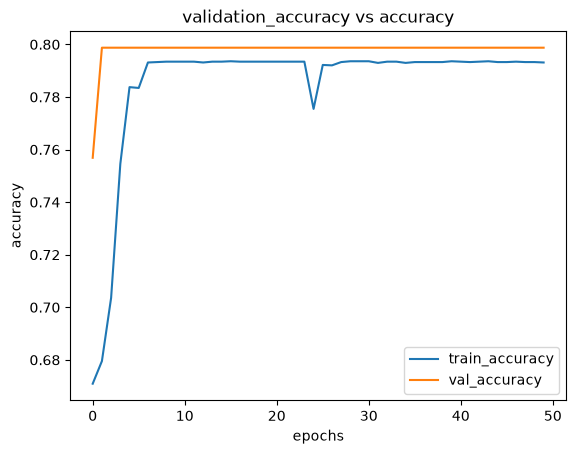

In [46]:
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('validation_accuracy vs accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
#          PLOT FOR LOSS CHANGES TO IMPORVE ACCURACY 

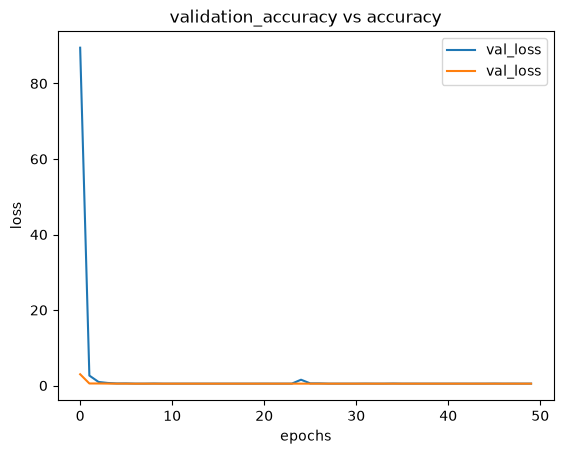

In [47]:
plt.plot(history.history['loss'],label='val_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('validation_accuracy vs accuracy')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
# HOW TO PREVENT MODEL FROM OVERFITTING 

# DROPOUT
# BATCH_NORMALIZATION
# WEIGHT INITIALIZATION
# REGULARIZATION
# EPOSCHS INCREASE
# TRY ADDING LAYERS
# TRY INCREASING NODES
# TRY CHANGING ACTIVATION 
# TRY CHANGING OPTIMIZERS
# TRY DATA AUGMENTATION 
# TRY KERAS TUNING